In [1]:
import numpy as np
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# sys.path.append('your_path_to_main_functions')  # Uncomment and set the correct path if main_functions.py is in a different directory	or not in your venv
import source.main_functions as ft



# Comparations between our numerical integrations and CLASS.

For running this cell you need to have our modified version of CLASS , which stocks not only the perturbations $\delta$, but also their derivative $\dot{\delta}= \frac{d\delta}{d \eta}$.

This version will create a .txt with all the important variables to get the numerical solutions. In this case, initials conditions for the Numerical Solution are taken from $\delta_m[k, a = a_{ini}] \equiv \delta_i$ and $\delta_m'[k, a = a_{ini}] \equiv \delta'_i$. The percent difference between numerical vs. CLASS solutions reveals, in principle, the goodnes of the chosen initial value $a_{ini}$; the precision of the subhorizon aproximation it is studied later.

## CLASS vs subhorizon aproximation in $\Lambda$ CDM.

k requested: 0.002 h/Mpc -> k found in df: 0.002 h/Mpc
a_initial: 0.0306, k_horizon: 0.0066 h/Mpc, k_selected: 0.0020 h/Mpc
k requested: 0.005 h/Mpc -> k found in df: 0.005 h/Mpc
a_initial: 0.0300, k_horizon: 0.0067 h/Mpc, k_selected: 0.0052 h/Mpc
k requested: 0.013 h/Mpc -> k found in df: 0.013 h/Mpc
a_initial: 0.0301, k_horizon: 0.0066 h/Mpc, k_selected: 0.0130 h/Mpc
k requested: 0.05 h/Mpc -> k found in df: 0.050 h/Mpc
a_initial: 0.0321, k_horizon: 0.0064 h/Mpc, k_selected: 0.0500 h/Mpc
k requested: 0.1 h/Mpc -> k found in df: 0.100 h/Mpc
a_initial: 0.0334, k_horizon: 0.0063 h/Mpc, k_selected: 0.1000 h/Mpc
k requested: 0.25 h/Mpc -> k found in df: 0.250 h/Mpc
a_initial: 0.0334, k_horizon: 0.0063 h/Mpc, k_selected: 0.2500 h/Mpc


/tmp/ipykernel_159177/1532892960.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


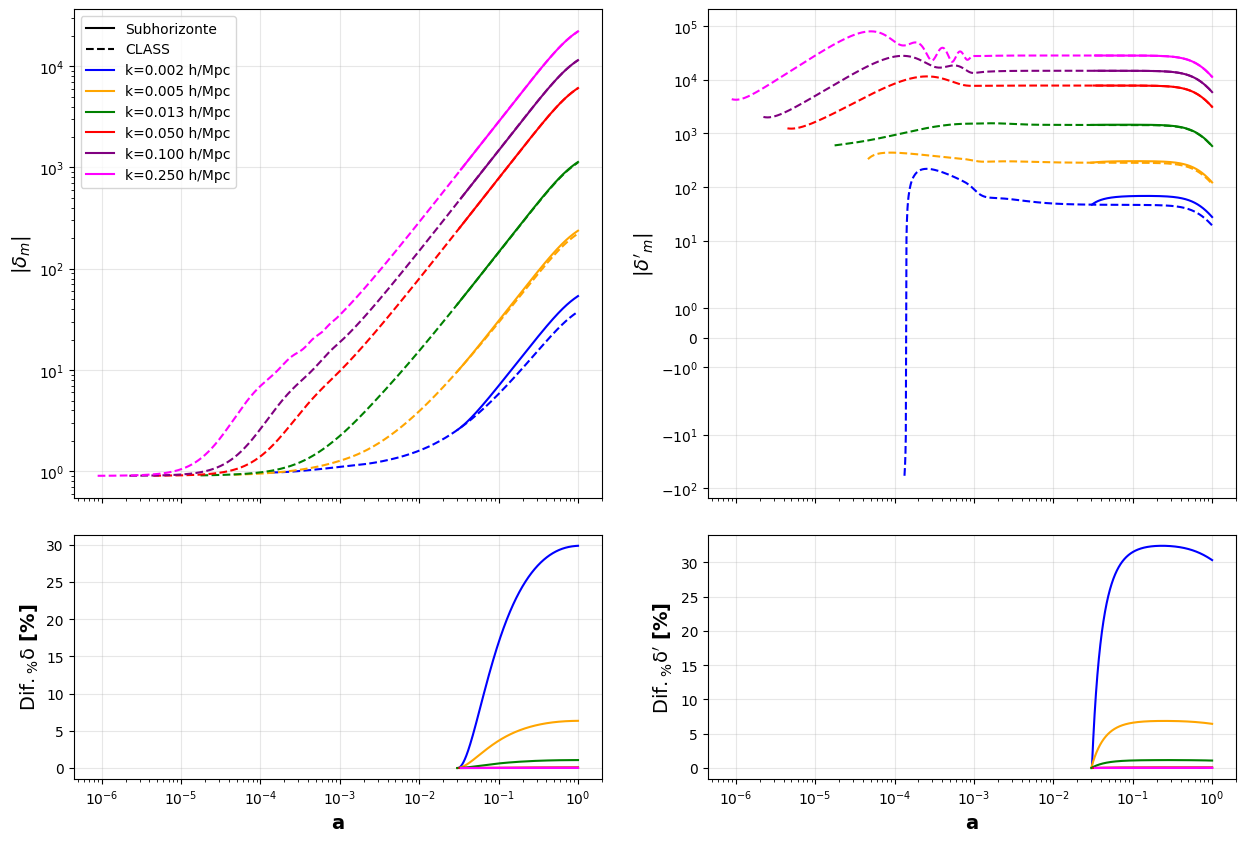

In [ ]:
import os
from matplotlib.lines import Line2D
from source.main_functions import NumericalIntegrator
import source.main_functions as ft

path_txt = '/home/pedrorozin/paper_tesis2025/delta_prime_cdm.txt'
k_thresholds = np.array([0.002, .005, .013, 0.05, .1, .25])  # h/Mpc
colors = ['blue', 'orange', 'green', 'red', 'purple', 'magenta']
h = .68
Omega_m = .3

a_query = 0.03
k_selected_list = []
difs_list = []
difs_primes_list = []
a_integrated_list = []
df_adhoc_list = []

if os.path.exists(path_txt):
    os.remove(path_txt)

M = ft.common_settings(k=0.01, omega_m=Omega_m, A_s=2.1e-9, h=h)
df_M = ft.get_df_from_M(M)
df_M = df_M.drop_duplicates(subset=['a'], keep='last')

Omega_b = M.Omega_b()
Omega_m_actual = M.Omega_m()
Omega_cdm = Omega_m_actual - Omega_b

# df from adhoc (CLASS en C)
df_adhoc = ft.read_adhoc_txt(path_txt)

for i, k_th in enumerate(k_thresholds):
    k_query_h_inv = k_th
    k_query_class_units = k_query_h_inv * h

    M = ft.common_settings(k=k_query_class_units, omega_m=Omega_m, A_s=2.1e-9, h=h)
    df_M = ft.get_df_from_M(M)
    df_M = df_M.drop_duplicates(subset=['a'], keep='last')

    Omega_b = M.Omega_b()
    Omega_m_actual = M.Omega_m()
    Omega_cdm = Omega_m_actual - Omega_b

    df_adhoc = ft.read_adhoc_txt(path_txt)

    k_selected = df_adhoc[df_adhoc['k'] >= k_query_class_units]['k'].min()
    k_selected_list.append(k_selected)
    print(f'k requested: {k_query_h_inv} h/Mpc -> k found in df: {k_selected/h:.3f} h/Mpc')

    df_adhoc_k = df_adhoc[df_adhoc['k'] == k_selected].copy()
    df_adhoc_k = df_adhoc_k.sort_values(by='a').drop_duplicates(subset=['a'], keep='last').reset_index(drop=True)

    delta_cdm_adhoc = df_adhoc_k['delta_cdm'].values
    delta_b_adhoc = df_adhoc_k['delta_b'].values
    delta_m_adhoc = ft.compute_delta_m(delta_cdm_adhoc, delta_b_adhoc, Omega_cdm, Omega_b)
    df_adhoc_k['delta_m'] = delta_m_adhoc
    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_cdm')
    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_b')
    delta_prime_m_adhoc = ft.compute_delta_m(
        df_adhoc_k['delta_prime_cdm'].values,
        df_adhoc_k['delta_prime_b'].values,
        Omega_cdm,
        Omega_b,
    )
    df_adhoc_k['delta_prime_m'] = delta_prime_m_adhoc

    initial_index = np.where(df_adhoc_k['a'] >= a_query)[0][0]
    a_initial = df_adhoc_k['a'].values[initial_index]
    delta_initial = df_adhoc_k['delta_m'].values[initial_index]
    delta_prime_initial = df_adhoc_k['delta_prime_m'].values[initial_index]

    k_horizon = ft.k_horizon(a_initial, Omega_m_actual, c=3e5)
    print(f'a_initial: {a_initial:.4f}, k_horizon: {k_horizon:.4f} h/Mpc, k_selected: {k_selected/h:.4f} h/Mpc')

    integrator = NumericalIntegrator(Om_m_0=Omega_m_actual, a_0=a_initial, sigma8=0.8)
    a_integrated, delta_integrated, delta_prime_integrated = integrator.integrate(delta_initial, delta_prime_initial)
    a_integrated_list.append(a_integrated)
    df_adhoc_list.append(df_adhoc_k.copy())

    M.struct_cleanup()
    del M

    dif = ft.percent_diff_vs_class(a_integrated, delta_integrated, df_adhoc_k['a'], df_adhoc_k['delta_m'])
    dif_primes = ft.percent_diff_vs_class(a_integrated, delta_prime_integrated, df_adhoc_k['a'], df_adhoc_k['delta_prime_m'])
    difs_list.append(dif)
    difs_primes_list.append(dif_primes)

if os.path.exists(path_txt):
    os.remove(path_txt)

fig, axs = plt.subplots(
    2,
    2,
    figsize=(15, 10),
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.1, 'wspace': 0.2},
    sharex='col',
)

ax_delta = axs[0, 0]
ax_delta_prime = axs[0, 1]
ax_dif_delta = axs[1, 0]
ax_dif_delta_prime = axs[1, 1]

line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='Subhorizonte'),
    Line2D([0], [0], color='black', linestyle='--', label='CLASS'),
]
color_elements = []

for i, (k_sel, df_adhoc_k, a_integrated) in enumerate(zip(k_selected_list, df_adhoc_list, a_integrated_list)):
    initial_index = np.where(df_adhoc_k['a'] >= a_query)[0][0]
    a_initial = df_adhoc_k['a'].values[initial_index]
    delta_initial = df_adhoc_k['delta_m'].values[initial_index]
    delta_prime_initial = df_adhoc_k['delta_prime_m'].values[initial_index]

    integrator = NumericalIntegrator(Om_m_0=Omega_m_actual, a_0=a_initial, sigma8=0.8)
    a_integrated, delta_integrated, delta_prime_integrated = integrator.integrate(delta_initial, delta_prime_initial)

    color = colors[i]
    ax_delta.plot(df_adhoc_k['a'], -df_adhoc_k['delta_m'], linestyle='--', color=color)
    ax_delta.plot(a_integrated, -delta_integrated, '-', color=color)
    ax_delta_prime.plot(df_adhoc_k['a'], -df_adhoc_k['delta_prime_m'], linestyle='--', color=color)
    ax_delta_prime.plot(a_integrated, -delta_prime_integrated, '-', color=color)
    ax_dif_delta.plot(a_integrated, difs_list[i], linestyle='-', color=color)
    ax_dif_delta_prime.plot(a_integrated, difs_primes_list[i], linestyle='-', color=color)
    color_elements.append(Line2D([0], [0], color=color, linestyle='-', label=f'k={k_sel/h:.3f} h/Mpc'))

ax_delta.set_yscale('log')
ax_delta.set_xscale('log')
ax_delta.set_ylabel(r'$|\delta_m|$', fontweight='bold', fontsize=14)
ax_delta.grid(alpha=0.3)
ax_delta.legend(handles=line_style_elements + color_elements, loc='upper left', fontsize=10)
ax_delta.tick_params(labelbottom=False)

ax_delta_prime.set_yscale('symlog')
ax_delta_prime.set_xscale('log')
ax_delta_prime.set_ylabel(r"$|\delta'_m|$", fontweight='bold', fontsize=14)
ax_delta_prime.grid(alpha=0.3)
ax_delta_prime.tick_params(labelbottom=False)

ax_dif_delta.set_xscale('log')
ax_dif_delta.set_ylabel(r'$\mathrm{Dif._\% \delta}$ [%]', fontweight='bold', fontsize=14)
ax_dif_delta.set_xlabel('a', fontweight='bold', fontsize=14)
ax_dif_delta.grid(alpha=0.3)

ax_dif_delta_prime.set_xscale('log')
ax_dif_delta_prime.set_ylabel(r'$\mathrm{Dif._\% \delta^\prime}$ [%]', fontweight='bold', fontsize=14)
ax_dif_delta_prime.set_xlabel('a', fontweight='bold', fontsize=14)
ax_dif_delta_prime.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  2x2 plot with deltas, deltas_prime y and percent dif. of cdm vs matter

This section is meant to corroborate if matter behaves as dark matter at our integration starting point.

In [2]:
path = '/home/pedrorozin/paper_tesis2025/delta_prime_cdm.txt'

Omega_cdm = .25
Omega_b = .05
Omega_m = Omega_cdm + Omega_b
h = .68
A_s = 2.0e-9
print(f"Omega_cdm: {Omega_cdm}, Omega_b: {Omega_b}, h: {h}, A_s: {A_s}")

if os.path.exists(path):
	os.remove(path)
 
_M = ft.common_settings(k=0.01, omega_m=Omega_m, A_s=A_s, h=h) #this creates a .txt with the results of CLASS in C for the given parameters

df = ft.read_adhoc_txt(path)
delta_m = ft.compute_delta_m(df['delta_cdm'], df['delta_b'], Omega_cdm, Omega_b)
df['delta_m'] = delta_m
df = ft.deriv_tau_to_a(df, 'delta_dot_cdm')
df = ft.deriv_tau_to_a(df, 'delta_dot_b')
df['delta_prime_m'] = ft.compute_delta_m(df['delta_prime_cdm'], df['delta_prime_b'], Omega_cdm, Omega_b)

df.head()

Omega_cdm: 0.25, Omega_b: 0.05, h: 0.68, A_s: 2e-09


,delta_cdm,delta_dot_cdm,delta_b,delta_dot_b,a,k,H,delta_m,delta_prime_cdm,delta_prime_b,delta_prime_m
0,-0.902729,-0.014653,-0.902729,-0.014650,5.450249e-07,0.277316,3.961663,-0.902729,-6786.141257,-6784.918585,-6785.937478
1,-0.902520,-0.055410,-0.902520,-0.055400,1.360880e-07,1.109885,15.855500,-0.902520,-25679.760151,-25674.856880,-25678.942939
2,-0.902520,-0.055410,-0.902520,-0.055400,1.360880e-07,1.109885,15.855500,-0.902520,-25679.760151,-25674.856880,-25678.942939
3,-0.902520,-0.055410,-0.902520,-0.055399,1.360880e-07,1.109885,15.855500,-0.902520,-25679.644289,-25674.741018,-25678.827077
4,-0.902729,-0.014653,-0.902729,-0.014650,5.450249e-07,0.277316,3.961663,-0.902729,-6786.141257,-6784.918585,-6785.937478


Primer valor de a donde |dif δ'| < 1%: 0.0082


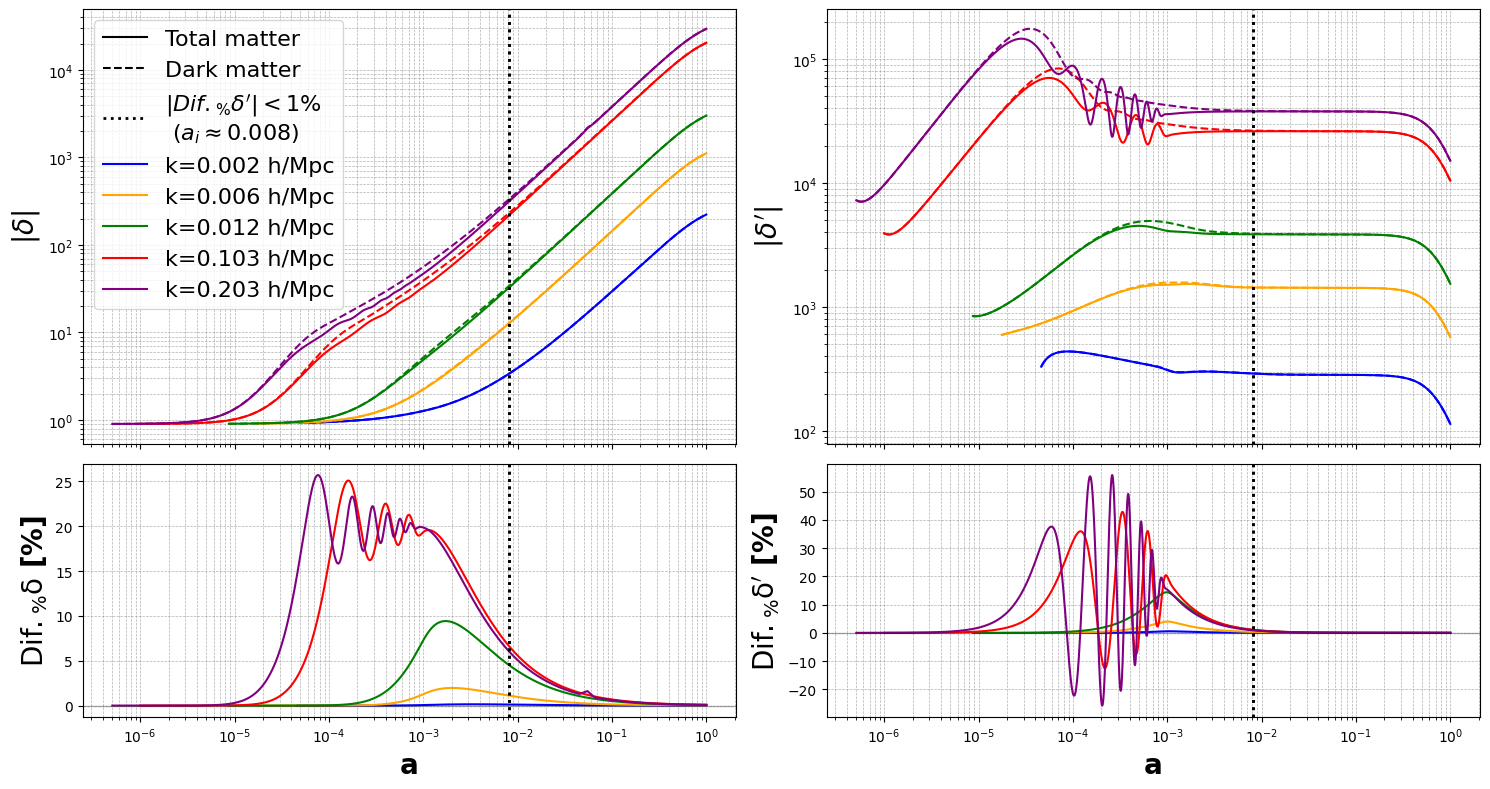

In [ ]:
#import Line2D
from matplotlib.lines import Line2D
k_thresholds = np.array([0.002,.005,.01, .1, .2])/h #h/Mpc
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
# lista_dif_rel =[]
arrs_difs = np.zeros((len(k_thresholds), len(df['a'].unique())))

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 8), sharex='col',
                        gridspec_kw={'height_ratios': [3, 1.75]})
#share y in second row
# axs[1,0].sharey(axs[1,1])
line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='Total matter'),
    Line2D([0], [0], color='black', linestyle='--', label='Dark matter')
]
line_style_elements2 = [
    Line2D([0], [0], color='black', linestyle='-', label='$\delta\'_m$'),
    Line2D([0], [0], color='black', linestyle='--', label='$\delta\'_{cdm}$')
]
color_elements =[]

for i, k_th in enumerate(k_thresholds):
    df_filtered = df[df['k'] >= k_th]
    if df_filtered.empty:
        print(f"No hay k >= {k_th}")
        continue
    k_sel = df_filtered['k'].min()
    df_k = df[df['k'] == k_sel].copy()
    df_k = df_k.sort_values(by='a').reset_index(drop=True)
    #delete duplicates
    df_k = df_k.drop_duplicates(subset=['a'], keep='first')
    color = colors[i]
    dif = ft.percent_diff_vs_class(df_k['a'], df_k['delta_m'], df_k['a'], df_k['delta_cdm'])
    dif_primes = ft.percent_diff_vs_class(df_k['a'], df_k['delta_prime_cdm'], df_k['a'], df_k['delta_prime_m'])
    # lista_dif_rel.append(dif)
    # arrs_difs[i, :] = dif
    dic_difs = {f'k={k_sel:<.3f}': dif}

    # Fila superior: delta (izq) y delta_prime (der)
    axs[0,0].plot(
        df_k['a'], -df_k['delta_m'],linestyle ='-', color=color
        )
    axs[0,0].plot(
        df_k['a'], -df_k['delta_cdm'], '--', color=color
    )
    axs[0,1].plot(
        df_k['a'], -df_k['delta_prime_m'], linestyle='-', color=color
    )
    axs[0,1].plot(
        df_k['a'], -df_k['delta_prime_cdm'], '--', color=color
    )
    
    # Fila inferior: diferencias percentuales
    axs[1,0].plot(
        df_k['a'], -dif, linestyle='-', color=color
    )
    axs[1,1].plot(
        df_k['a'], dif_primes, linestyle='-', color=color
    )
    
    # Encontrar el valor de 'a' donde |dif_primes| < 1% (solo para la primera curva)
    if i == 4:
        mask_below_1 = (np.abs(dif_primes) < 1.0) & (df_k['a'] > 0.005)
        if np.any(mask_below_1):
            a_threshold = df_k['a'].values[mask_below_1][0]
            print(f'Primer valor de a donde |dif δ\'| < 1%: {a_threshold:.4f}')
    
    # append color legends
    color_elements.append(
        Line2D([0], [0], color=color, linestyle='-', label=f'k={k_sel*h:<.3f} h/Mpc')
    )
# #grid in all subplots
# for ax in axs.flat:
#     ax.grid(alpha=True)


axs[0,0].set_yscale('log')
axs[0,0].set_xscale('log')
axs[0,1].set_yscale('log')
axs[0,1].set_xscale('log')
axs[1,0].set_xscale('log')
axs[1,1].set_xscale('log')

# 2. Labels
axs[0,0].set_ylabel(r'$|\delta|$', fontweight='bold', fontsize=20)
axs[0,1].set_ylabel(r"$|\delta'|$", fontweight='bold', fontsize=20)
axs[1,0].set_ylabel(r'$\mathrm{Dif._\% \delta}$ [%]', fontweight='bold', fontsize=20)
axs[1,1].set_ylabel(r"$\mathrm{Dif._\% \delta}'$ [%]", fontweight='bold', fontsize=20)
axs[1,0].set_xlabel('a', fontweight='bold', fontsize=20)
axs[1,1].set_xlabel('a', fontweight='bold', fontsize=20)

# 3. grid style

for ax in axs.flat:
    # 'which="both"' activates the lines for mayor and minor ticks
    # 'zorder=0' o 'set_axisbelow' asegura que el grid quede DETRÁS de las curvas
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6, color='gray')
    ax.set_axisbelow(True) 

# Líneas de referencia horizontales
axs[1,0].axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)
axs[1,1].axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.3)

# Línea vertical del threshold (tu lógica original)
if 'a_threshold' in locals():
    # Creamos el elemento de leyenda solo una vez para evitar duplicados
    line_style_threshold = Line2D([0], [0], color='black', linestyle=':', linewidth=2, 
                                label=f"|$Dif._\% \delta'$| < 1%\n($a_i=${a_threshold:.3f})")
    
    for ax in axs.flat:
        ax.axvline(x=a_threshold, color='black', linestyle=':', linewidth=2)
        
handles_p00 = line_style_elements
if a_threshold is not None:
    line_style_threshold = Line2D([0], [0], color='black', linestyle=':', linewidth=2, 
                                label=f"$|Dif._\% \delta'|<1\%$ \n $(a_i\\approx{a_threshold:.3f})$")
        
    for ax in axs.flat:
        ax.axvline(x=a_threshold, color='black', linestyle=':', linewidth=2)
        # Sombreado de la zona "mala" (oscilaciones)
        # ax.axvspan(1e-7, a_threshold, color='gray', alpha=0.15, zorder=0)

# Leyendas Organizadas
    handles_p00.append(line_style_threshold)

axs[0,0].legend(handles=handles_p00 + color_elements, loc='upper left', fontsize=16)
# axs[0,0].legend(handles=color_elements, loc='best', title="Escalas $k$", fontsize=9, ncol=1)

plt.tight_layout()

#save fig in outputs_pedro
# plt.savefig('/home/pedrorozin/scripts/outputs_pedro/comparaciones_delta_prime_cdm.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
#print dif when a=0.05
dif_at_005 = dif[np.argmin(np.abs(df_k['a'] - 0.05))]
dif_prime_at_005 = dif_primes[np.argmin(np.abs(df_k['a'] - 0.05))]

print(f'Dif. delta_cdm vs delta_m at a=0.05: {dif_at_005}%')
print(f'Dif. delta_prime_cdm vs delta_prime_m at a=0.05: {dif_prime_at_005}%')

Dif. delta_cdm vs delta_m at a=0.05: -1.281949017599601%
Dif. delta_prime_cdm vs delta_prime_m at a=0.05: 0.06947420197027442%


## Verification of the parameters space

We want to ensure that the numerical integration it is still reasonable for extremal values of $H_0$ and $\Omega_m$ that denotes the limit of our training data. For doing that, we check if: i) total matter behaves as dark matter at the integration starting point $a_{ini}$ (i.e, BAO's are no longer relevant for the dinamic of $\delta_m$); ii) $\Lambda$ CDM and Hu-Sawicki describe the same dinamic.


### BAOs

Omega_m: 0.45000000000000007, Omega_b: 0.04867734979810887, Omega_cdm: 0.4013226502018912
k selected from adhoc: 0.0198
a_initial: 0.008105363, k_horizon: 0.015799012452013542 h/Mpc, k_selected: 0.030000000000000002 h/Mpc


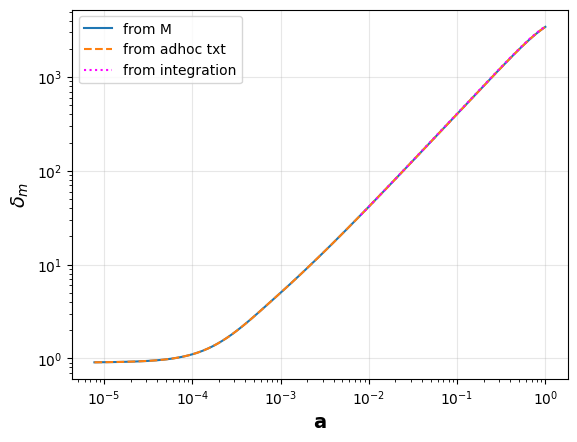

In [ ]:
from source.main_functions import NumericalIntegrator

# df que sale del get_perturbations() del CLASS en python

h = 0.66
k_query_h = 0.03
k_query = k_query_h * h
Omega_m_target = 0.45
path_txt = '/home/pedrorozin/paper_tesis2025/delta_prime_cdm.txt'
a_query = 8e-3

if os.path.exists(path_txt):
    os.remove(path_txt)

M = ft.common_settings(k=k_query, omega_m=Omega_m_target, A_s=2.1e-9, h=h)
df_M = ft.get_df_from_M(M)
df_M = df_M.drop_duplicates(subset=['a'], keep='last').sort_values(by='a').reset_index(drop=True)

Omega_b = M.Omega_b()
Omega_m = M.Omega_m()  # es el mismo que Omega_m_target, salvo redondeos internos
Omega_cdm = Omega_m - Omega_b
print(f'Omega_m: {Omega_m}, Omega_b: {Omega_b}, Omega_cdm: {Omega_cdm}')

# delta y delta_prime
Delta_cdm_M = df_M['delta_cdm'].values
delta_b_M = df_M['delta_b'].values
delta_m_M = ft.compute_delta_m(Delta_cdm_M, delta_b_M, Omega_cdm, Omega_b)

#==================================
# df from adhoc que sale del codigo en C
#==================================

df_adhoc = ft.read_adhoc_txt(path_txt)
if os.path.exists(path_txt):
    os.remove(path_txt)

k_selected = df_adhoc[df_adhoc['k'] >= k_query]['k'].min()
print(f'k selected from adhoc: {k_selected}')

df_adhoc_k = df_adhoc[df_adhoc['k'] == k_selected].copy()
df_adhoc_k = df_adhoc_k.sort_values(by='a').drop_duplicates(subset=['a'], keep='last').reset_index(drop=True)

# delta y delta_prime
delta_cdm_adhoc = df_adhoc_k['delta_cdm'].values
delta_b_adhoc = df_adhoc_k['delta_b'].values
delta_m_adhoc = ft.compute_delta_m(delta_cdm_adhoc, delta_b_adhoc, Omega_cdm, Omega_b)
df_adhoc_k['delta_m'] = delta_m_adhoc
df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_cdm')
df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_b')
delta_prime_m_adhoc = ft.compute_delta_m(df_adhoc_k['delta_prime_cdm'].values, df_adhoc_k['delta_prime_b'].values, Omega_cdm, Omega_b)
df_adhoc_k['delta_prime_m'] = delta_prime_m_adhoc

#==============================
# curvas de integracion
#==============================
initial_index = np.where(df_adhoc_k['a'] >= a_query)[0][0]
a_initial = df_adhoc_k['a'].values[initial_index]
k_horizon = ft.k_horizon(a_initial, Omega_m, c=3e5)
print(f'a_initial: {a_initial}, k_horizon: {k_horizon} h/Mpc, k_selected: {k_selected/h} h/Mpc')

delta_initial = df_adhoc_k['delta_m'].values[initial_index]
delta_prime_initial = df_adhoc_k['delta_prime_m'].values[initial_index]

integrator = NumericalIntegrator(Om_m_0=Omega_m, a_0=a_initial, sigma8=0.8)
a_integrated, delta_integrated, delta_prime_integrated = integrator.integrate(delta_initial, delta_prime_initial)

#==============================
# plots
#==============================
plt.plot(df_M['a'], -delta_m_M, label='from M', linestyle='-')
# plt.plot(df_M2['a'], -ft.compute_delta_m(df_M2['delta_cdm'].values, df_M2['delta_b'].values, Omega_cdm, Omega_b), label='from M2', linestyle=':')
plt.plot(df_adhoc_k['a'], -delta_m_adhoc, label='from adhoc txt', linestyle='--')
plt.plot(a_integrated, -delta_integrated, label='from integration', color='magenta', linestyle=':')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('a', fontweight='bold', fontsize=14)
plt.ylabel('$\delta_{m}$', fontweight='bold', fontsize=14)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

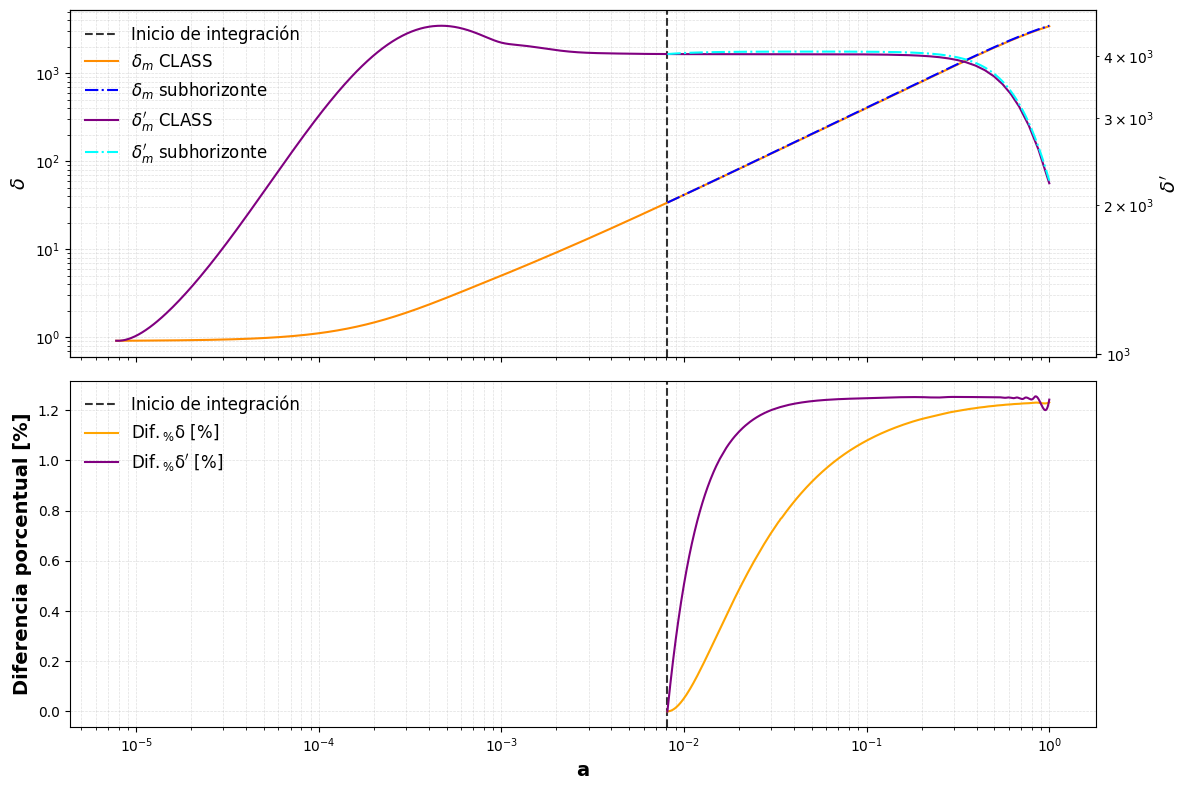

In [ ]:
dif_python_vs_adhoc = ft.percent_diff_vs_class(df_M['a'], delta_m_M, df_adhoc_k['a'], delta_m_adhoc)
dif_python_vs_integrated = ft.percent_diff_vs_class(a_integrated, delta_integrated, df_M['a'], delta_m_M)
dif_adhoc_vs_integrated = ft.percent_diff_vs_class(a_integrated, delta_integrated,df_adhoc_k['a'], df_adhoc_k['delta_m'])
dif_deltas_prime = ft.percent_diff_vs_class(a_integrated, delta_prime_integrated, df_adhoc_k['a'], df_adhoc_k['delta_prime_m'])


# Figura con dos filas
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ===================== FILA SUPERIOR =====================
ax1 = axs[0]
ax2 = ax1.twinx()

#title
# ax1.set_title(f"Comparación Red Neuronal vs Grilla\n \n {params}")
# δ

# ax1.plot(df_M['a'], -delta_m_M, label='δ python', color="orange", ls="-")
ax1.axvline(x=a_integrated[0], color='black', linestyle='--', linewidth=1.5, alpha=0.8, label = 'Inicio de integración')
ax1.plot(df_adhoc_k['a'], -delta_m_adhoc, label=r'$\delta_m$ CLASS', color="darkorange", ls="-")
ax1.plot(a_integrated, -delta_integrated, label=r'$\delta_m$ subhorizonte', color="blue", ls="-.")
ax1.set_ylabel(r"$\delta$", fontsize=14, color="black", fontweight="bold")
ax1.set_yscale("log")
ax1.set_xscale("log")
#vline in start of integration

# ax1.tick_params(axis="y", labelcolor="C0")
ax1.tick_params(axis = "y")
ax1.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.4)

# δ′

ax2.plot(df_adhoc_k['a'], -df_adhoc_k['delta_prime_m'], label=r"$\delta^{\prime}_m$ CLASS", color="purple", ls="-")
ax2.plot(a_integrated, -delta_prime_integrated, label=r"$\delta^{\prime}_m$ subhorizonte", color= "cyan", ls="-.")
ax2.set_ylabel(r"$\delta^{\prime}$", fontsize=14, color="black", fontweight="bold")
ax2.set_yscale("log")
ax2.set_xscale("log")
#ax2 yticks every 10^4
# ax2.yaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=2))
ax2.tick_params(axis="y")

# Leyenda combinada arriba
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2,  fontsize=12, frameon=False, loc = 'best')

# ===================== FILA INFERIOR =====================
ax3 = axs[1]

# Usamos un solo eje y

ax3.axvline(x=a_integrated[0], color='black', linestyle='--', linewidth=1.5, alpha=0.8, label = 'Inicio de integración')
ax3.plot(a_integrated, np.abs(dif_adhoc_vs_integrated), label=r"$\mathrm{Dif._\% \delta}$ [%]", color="orange", ls="-")
ax3.plot(a_integrated, np.abs(dif_deltas_prime), label=r"$\mathrm{Dif._\% \delta}'$ [%]", color="purple", ls="-")
ax3.set_ylabel("Diferencia porcentual [%]", fontsize=14, fontweight="bold")



ax3.set_yscale("linear") 

ax3.set_xscale("log")
ax3.grid(True, which="both", ls="--", linewidth=0.5, alpha=0.4)

# Leyenda abajo
ax3.legend(loc="best", fontsize=12, frameon=False)
# Label común de x
ax3.set_xlabel("a", fontsize=14, fontweight ='bold')

plt.tight_layout()
plt.show()

### espacio de parametros heatmap

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
import os
import pandas as pd
from tqdm import tqdm
import source.main_functions as ft 

# --- 1. CONFIGURACIÓN ---
resolution = 20 # Subí un poquito para ver mejor el gradiente
omega_m_vals = np.linspace(0.1, 0.45, resolution) 
h0_vals = np.linspace(64, 76, resolution)

k_target_h = 0.15    # [h/Mpc]
a_target = 0.03      # a_i

omega_b_fixed = 0.05 

error_grid = np.zeros((len(h0_vals), len(omega_m_vals)))

adhoc_file_path = '/home/pedrorozin/paper_tesis2025/delta_prime_cdm.txt'

print(f"Generando Heatmap para {resolution*resolution} cosmologías...")

for i, h0 in tqdm(enumerate(h0_vals), desc="Recorriendo H0"):
    for j, om in enumerate(omega_m_vals):
        # omega_b = om/6
        omega_b = omega_b_fixed
        # 1. Variables del bucle actual
        h_param = h0 / 100.0
        omega_cdm = om - omega_b
        k_class = k_target_h * h_param # Convertir a 1/Mpc para CLASS
        
        # 2. Limpieza preventiva del archivo adhoc anterior
        # Esto asegura que si CLASS falla, no leas el archivo viejo por error
        if os.path.exists(adhoc_file_path):
            os.remove(adhoc_file_path)

        # 3. Correr CLASS (CORRECCIÓN AQUÍ: Usar variables del bucle)
        # Nota: Asumo que ft.common_settings llama a M.compute() y eso genera el .txt
        try:
            cosmo = ft.common_settings(
                k=k_class,          # USAR k_class (del bucle), NO k_query
                omega_m=om,         # USAR om (del bucle), NO Omega_m
                h=h_param,          # USAR h_param (del bucle), NO h
                A_s=2.1e-9
            )
        except Exception as e:
            print(f"CLASS falló en om={om}, h={h0}: {e}")
            error_grid[i, j] = np.nan
            continue

        # 4. Verificar que se generó el archivo nuevo
        if not os.path.exists(adhoc_file_path):
            print(f"Error: CLASS corrió pero no generó {adhoc_file_path}")
            error_grid[i, j] = np.nan
            cosmo.struct_cleanup()
            cosmo.empty()
            continue

        # 5. Leer datos del archivo adhoc
        try:
            df_adhoc = ft.read_adhoc_txt(adhoc_file_path)
            
            # Filtro por k (El archivo podría tener varios k si no se limpia bien, asegúrate de tomar el correcto)
            # Como borramos el archivo antes, debería haber solo uno, pero mantenemos tu lógica por seguridad
            # k_query no existe aquí, usamos k_class (que está en 1/Mpc igual que el output de class)
            # OJO: Chequear en qué unidades escribe tu txt el 'k'. Si es h/Mpc o 1/Mpc.
            # Asumo que escribe lo que le entra.
            
            # Selección del k más cercano para evitar problemas de float
            k_unique = df_adhoc['k'].unique()
            k_selected = k_unique[np.argmin(np.abs(k_unique - k_class))]
            
            df_k = df_adhoc[df_adhoc['k'] == k_selected].copy()
            df_k = df_k.sort_values(by='a').drop_duplicates(subset=['a'], keep='last')

            # 6. Calcular Deltas y Derivadas
            # Asumiendo que tu archivo txt YA TIENE las derivadas temporales (delta_dot)
            # Convertimos a derivadas respecto a 'a' (delta_prime)
            
            # Reconstruir Delta M (Total)
            delta_m_vals = ft.compute_delta_m(
                df_k['delta_cdm'].values, 
                df_k['delta_b'].values, 
                omega_cdm, 
                omega_b_fixed
            )
            
            # Convertir derivadas de tiempo (tau) a factor de escala (a)
            # Tu función ft.deriv_tau_to_a agrega la columna 'delta_prime_X'
            df_k = ft.deriv_tau_to_a(df_k, 'delta_dot_cdm') # Crea 'delta_prime_cdm'
            df_k = ft.deriv_tau_to_a(df_k, 'delta_dot_b')   # Crea 'delta_prime_b'
            
            # Calcular derivada de materia total combinando las derivadas de componentes
            delta_prime_m_vals = ft.compute_delta_m(
                df_k['delta_prime_cdm'].values, 
                df_k['delta_prime_b'].values, 
                omega_cdm, 
                omega_b_fixed
            )
            
            # 7. Obtener valores en a_target
            a_vec = df_k['a'].values
            
            # Interpolación simple (vecino más cercano) o spline
            idx = np.argmin(np.abs(a_vec - a_target))
            
            val_prime_m = delta_prime_m_vals[idx]
            val_prime_cdm = df_k['delta_prime_cdm'].values[idx]
            
            # 8. Calcular Error
            diff = abs((val_prime_m - val_prime_cdm) / val_prime_m) * 100
            error_grid[i, j] = diff
            
        except Exception as e:
            print(f"Error procesando datos en om={om}, h={h0}: {e}")
            error_grid[i, j] = np.nan
        
        # Limpieza de memoria de CLASS
        cosmo.struct_cleanup()
        cosmo.empty()



Generando Heatmap para 400 cosmologías...


Recorriendo H0: 20it [05:46, 17.35s/it]


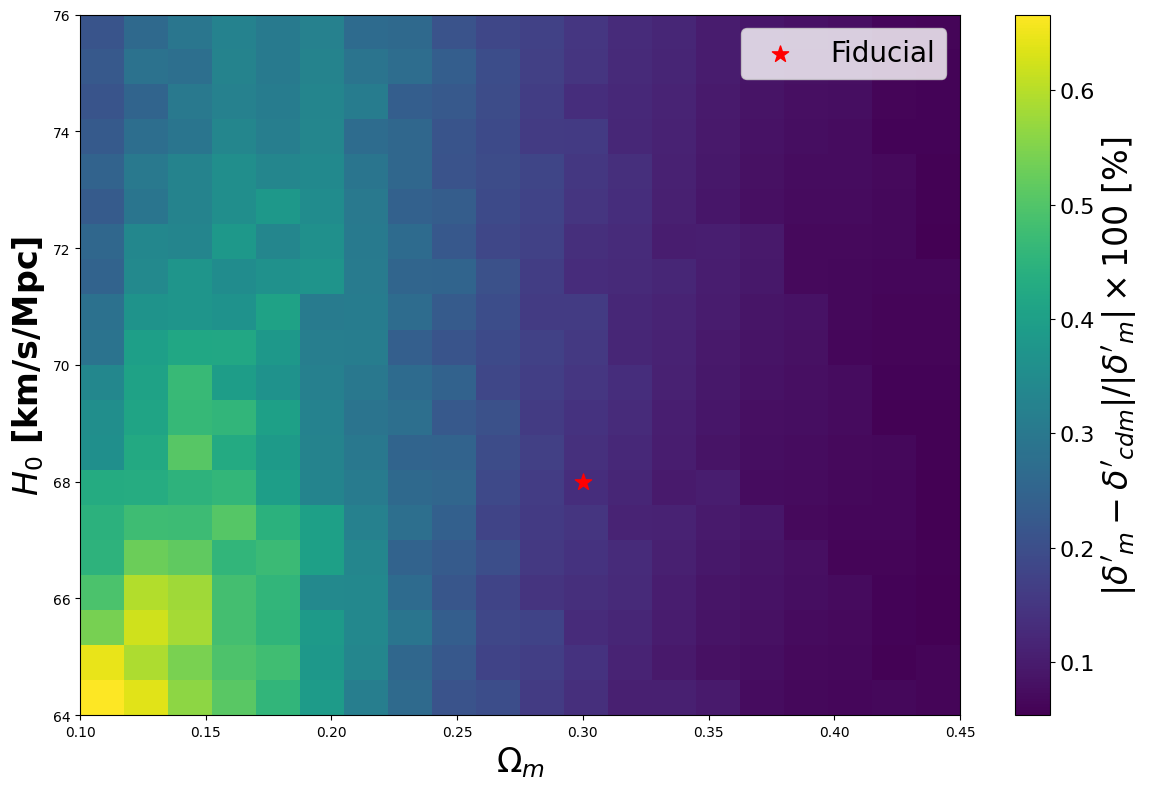

Error Máximo: 0.6663%


In [6]:
plt.figure(figsize=(12, 8))
extent = [omega_m_vals.min(), omega_m_vals.max(), h0_vals.min(), h0_vals.max()]

plt.imshow(error_grid, extent=extent, origin='lower', aspect='auto', cmap='viridis')
cbar = plt.colorbar()
cbar.set_label(r"$|\delta'_m - \delta'_{cdm}| / |\delta'_m|\times 100$ [%]", fontsize=24)
#bigger ticks in cbar
cbar.ax.tick_params(labelsize=16)

CS = plt.contour(error_grid, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')
plt.clabel(CS, fmt='%1.1f%%', inline=True, fontsize=16)

plt.xlabel(r'$\Omega_m$', fontsize=24, fontweight='bold')
plt.ylabel(r'$H_0$ [km/s/Mpc]', fontsize=24, fontweight='bold')
# plt.title(f'Validación ($a_i={a_target}, k \\approx {k_target_h} h/Mpc$)', fontsize=14)
plt.scatter([0.3], [68], color='red', marker='*', s=150, label='Fiducial', zorder=10)
#punto en maximo error
# plt.scatter([omega_m_vals[np.nanargmax(error_grid)%resolution]], [h0_vals[np.nanargmax(error_grid)//resolution]], color='black', marker='x', s=100, label='Error Máximo', zorder=10)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()

print(f"Error Máximo: {np.nanmax(error_grid):.4f}%")

### HS vs $\Lambda$ CDM

Generando Heatmaps MG vs LCDM...
Inicio: a=0.008 -> Evaluar en: a=0.03
Parámetros: k=0.2 h/Mpc, b=1


Procesando: 20it [15:07, 45.38s/it]


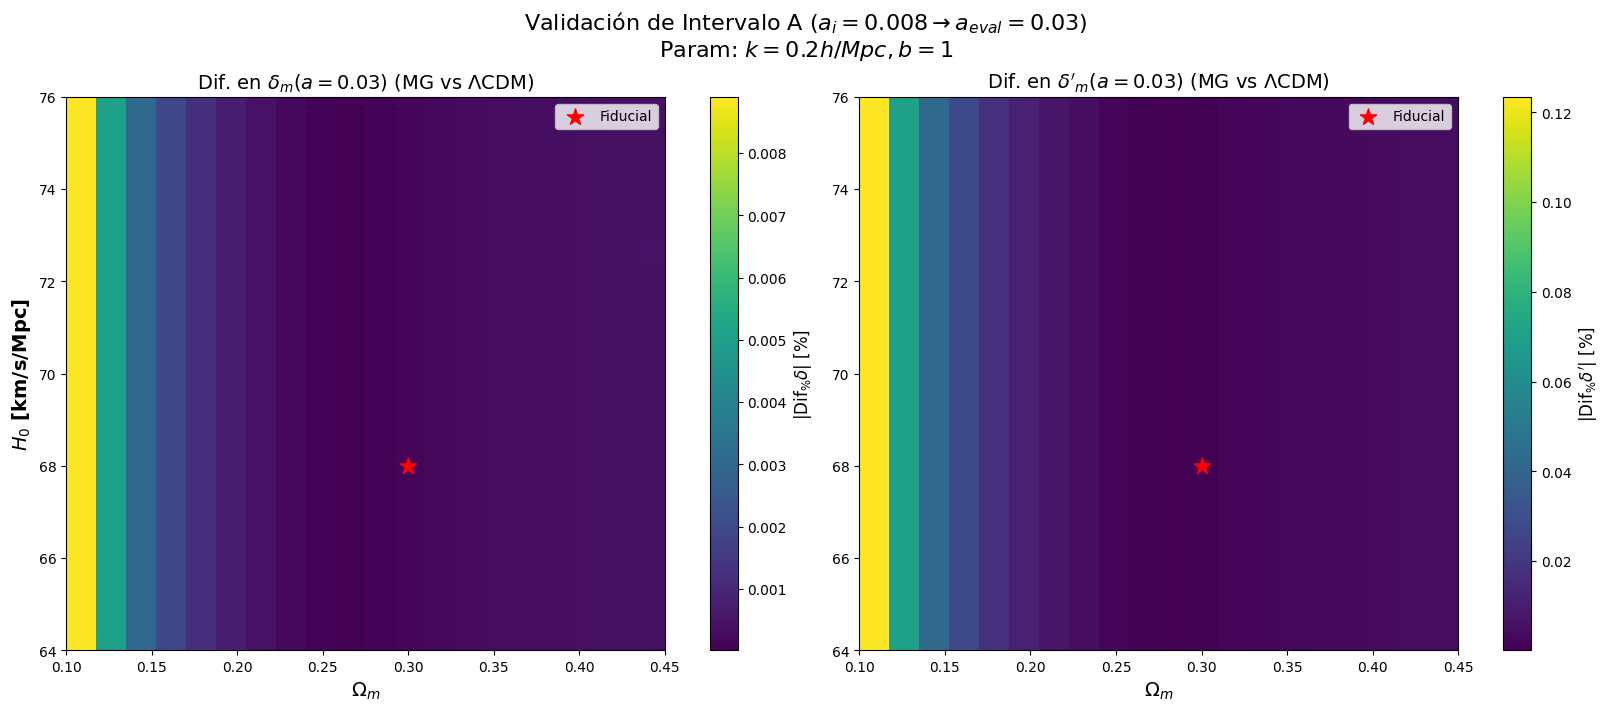

Máx dif Delta': 0.1235%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import sys, importlib
importlib.reload(sys.modules['source.delta_solver_mg_pedro'])
import main_functions as ft 
from source.delta_solver_mg_pedro import VectorizedDeltaSolver


# --- 1. CONFIGURACIÓN ---
resolution = 20
omega_m_vals = np.linspace(0.1, 0.45, resolution) 
h0_vals = np.linspace(64, 76, resolution)

# Parámetros fijos
k_target_h = 0.2      # [h/Mpc]
a_start = 0.008       # Inicio de integración (condición inicial común)
a_eval = 0.03         # Punto de evaluación (donde chequeamos la diferencia)
b_param = 1        # Parámetro Hu-Sawicki (caso extremo conservador)


# Matrices para guardar los errores
grid_diff_delta = np.zeros((len(h0_vals), len(omega_m_vals)))
grid_diff_prime = np.zeros((len(h0_vals), len(omega_m_vals)))

print(f"Generando Heatmaps MG vs LCDM...")
print(f"Inicio: a={a_start} -> Evaluar en: a={a_eval}")
print(f"Parámetros: k={k_target_h} h/Mpc, b={b_param}")

# --- 2. BUCLE SOBRE EL ESPACIO DE PARÁMETROS ---
for i, h0 in tqdm(enumerate(h0_vals), desc="Procesando"):
    for j, om in enumerate(omega_m_vals):
        
        # Calcular parámetros derivados
        h_param = h0 / 100.0
        z_start = 1.0/a_start - 1.0 # Redshift inicial para el solver
        
        # Convertir k a 1/Mpc (unidades físicas para el solver)
        k_in_1_Mpc = k_target_h * h_param
        
        try:
            # Instanciar solver con inicio en a=0.008
            # Nota: k_array debe ser un array numpy
            solver = VectorizedDeltaSolver(
                k_array=np.array([k_in_1_Mpc]), 
                h=h_param, 
                Om_m_0=om, 
                b=b_param, 
                z_0=z_start,
                z_ini_HS=40,
                verbose=False
            )
            
            # Resolver ambos modelos (integración completa)
            # MG
            a_vec_mg, delta_mg, delta_p_mg = solver.solve_delta_mg_vectorized_parallel(verbose=False)
            # LCDM
            a_vec_lcdm, delta_lcdm, delta_p_lcdm = solver.solve_delta_lcdm_vectorized_parallel(verbose=False)
            
            # --- 3. INTERPOLAR EN a = 0.03 ---
            # El solver devuelve arrays de evolución [n_k, n_pasos]
            # Tomamos el índice k=0
            d_mg_at_eval = np.interp(a_eval, a_vec_mg, delta_mg[0, :])
            d_lcdm_at_eval = np.interp(a_eval, a_vec_lcdm, delta_lcdm[0, :])
            
            p_mg_at_eval = np.interp(a_eval, a_vec_mg, delta_p_mg[0, :])
            p_lcdm_at_eval = np.interp(a_eval, a_vec_lcdm, delta_p_lcdm[0, :])
            
            # --- 4. CALCULAR DIFERENCIA PORCENTUAL ---
            if abs(d_lcdm_at_eval) > 1e-12:
                diff_d = abs((d_mg_at_eval - d_lcdm_at_eval) / d_lcdm_at_eval) * 100
            else:
                diff_d = 0.0
                
            if abs(p_lcdm_at_eval) > 1e-12:
                diff_p = abs((p_mg_at_eval - p_lcdm_at_eval) / p_lcdm_at_eval) * 100
            else:
                diff_p = 0.0
            
            grid_diff_delta[i, j] = diff_d
            grid_diff_prime[i, j] = diff_p
            
        except Exception as e:
            print(f"Error en h={h0}, om={om}: {e}")
            grid_diff_delta[i, j] = np.nan
            grid_diff_prime[i, j] = np.nan

# --- 5. GRAFICAR ---
fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
extent = [omega_m_vals.min(), omega_m_vals.max(), h0_vals.min(), h0_vals.max()]

# Heatmap 1: Delta
im1 = axs[0].imshow(grid_diff_delta, extent=extent, origin='lower', aspect='auto', cmap='viridis')
axs[0].set_title(rf'Dif. en $\delta_m(a={a_eval})$ (MG vs $\Lambda$CDM)', fontsize=14)
axs[0].set_xlabel(r'$\Omega_m$', fontsize=14, fontweight='bold')
axs[0].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=14, fontweight='bold')
cb1 = plt.colorbar(im1, ax=axs[0])
cb1.set_label(r'$|\mathrm{Dif}_{\%}\delta|$ [%]', fontsize=12)
# Contorno de 1%
axs[0].contour(grid_diff_delta, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')

# Heatmap 2: Delta Prime
im2 = axs[1].imshow(grid_diff_prime, extent=extent, origin='lower', aspect='auto', cmap='viridis')
axs[1].set_title(rf"Dif. en $\delta'_m(a={a_eval})$ (MG vs $\Lambda$CDM)", fontsize=14)
axs[1].set_xlabel(r'$\Omega_m$', fontsize=14, fontweight='bold')
cb2 = plt.colorbar(im2, ax=axs[1])
cb2.set_label(r"$|\mathrm{Dif}_{\%}\delta'|$ [%]", fontsize=12)
# Contorno de 1%
CS2 = axs[1].contour(grid_diff_prime, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')
axs[1].clabel(CS2, fmt='%1.1f%%', inline=True, fontsize=10)

# Título General
fig.suptitle(f'Validación de Intervalo A ($a_i={a_start} \\to a_{{eval}}={a_eval}$)\nParam: $k={k_target_h} h/Mpc, b={b_param}$', fontsize=16)

# Marcar fiducial
for ax in axs:
    ax.scatter([0.3], [68], color='red', marker='*', s=150, label='Fiducial', zorder=10)
    ax.legend(loc='upper right')

plt.show()

# Mensaje diagnóstico
print(f"Máx dif Delta': {np.nanmax(grid_diff_prime):.4f}%")
# if np.nanmax(grid_diff_prime) < 1.0:
#     print("CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.")
# else:
#     print("ATENCIÓN: Hay regiones donde MG se separa de LCDM antes de a=0.03.")

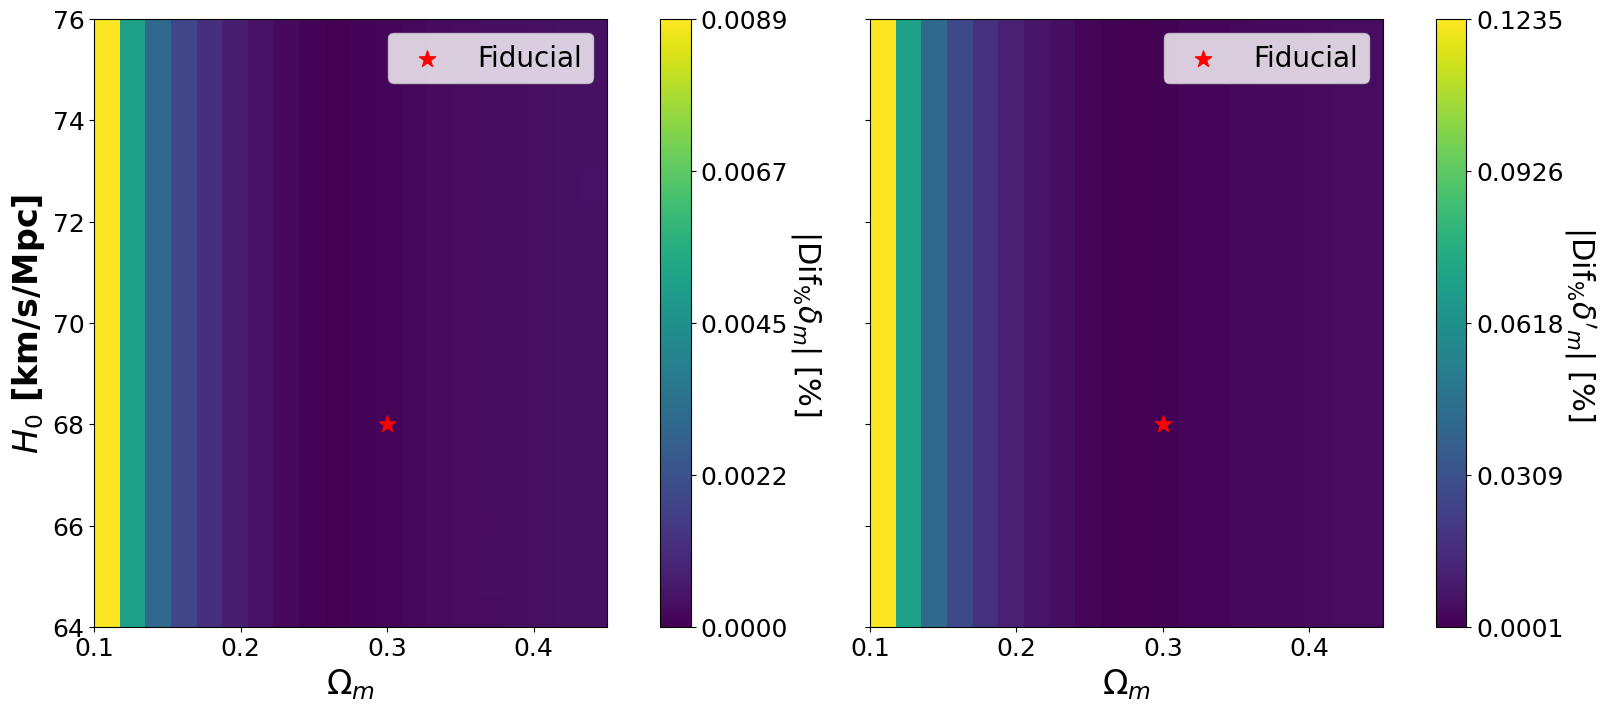

Máx dif Delta': 0.1235%
CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.


In [14]:
fig, axs = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True, sharey='row')
extent = [omega_m_vals.min(), omega_m_vals.max(), h0_vals.min(), h0_vals.max()]

# Heatmap 1: Delta
im1 = axs[0].imshow(grid_diff_delta, extent=extent, origin='lower', aspect='auto', cmap='viridis')
# axs[0].set_title(rf'Dif. en $\delta_m(a={a_eval})$ (MG vs $\Lambda$CDM)', fontsize=16)
axs[0].set_xlabel(r'$\Omega_m$', fontsize=24, fontweight='bold')
axs[0].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=24, fontweight='bold')
cb1 = plt.colorbar(im1, ax=axs[0])
cb1.set_label(r'$|\mathrm{Dif}_{\%}\delta_m|$ [%]', rotation=270, labelpad=25, fontsize=22)
cb1.ax.tick_params(labelsize=18)
# Set appropriate ticks for delta
tick_values_1 = np.linspace(grid_diff_delta.min(), grid_diff_delta.max(), 5)
cb1.set_ticks(tick_values_1)
cb1.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))

# Contorno de 1%
axs[0].contour(grid_diff_delta, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')

# Heatmap 2: Delta Prime
im2 = axs[1].imshow(grid_diff_prime, extent=extent, origin='lower', aspect='auto', cmap='viridis')
# axs[1].set_title(rf"Dif. en $\delta'_m(a={a_eval})$ (MG vs $\Lambda$CDM)", fontsize=14)
axs[1].set_xlabel(r'$\Omega_m$', fontsize=24, fontweight='bold')
# axs[1].set_ylabel(r'$H_0$ [km/s/Mpc]', fontsize=24, fontweight='bold')
cb2 = plt.colorbar(im2, ax=axs[1])
cb2.set_label(r"$|\mathrm{Dif}_{\%}\delta'_m|$ [%]", rotation=270, labelpad=25, fontsize=22)
cb2.ax.tick_params(labelsize=18)
# Set appropriate ticks for delta prime
tick_values_2 = np.linspace(grid_diff_prime.min(), grid_diff_prime.max(), 5)
cb2.set_ticks(tick_values_2)
cb2.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.4f}'))

# Contorno de 1%
CS2 = axs[1].contour(grid_diff_prime, levels=[1.0], extent=extent, origin='lower', colors='white', linestyles='--')
axs[1].clabel(CS2, fmt='%1.1f%%', inline=True, fontsize=24)

# Título General
# fig.suptitle(f'Validación de Intervalo A ($a_i={a_start} \\to a_{{eval}}={a_eval}$)\nParam: $k={k_target_h} h/Mpc, b={b_param}$', fontsize=16)

# Marcar fiducial
for ax in axs:
    ax.scatter([0.3], [68], color='red', marker='*', s=150, label='Fiducial', zorder=10)
    ax.legend(loc='upper right', fontsize=20)
    #bigger x and y ticks
    ax.tick_params(axis='both', which='major', labelsize=18)

plt.show()

# Mensaje diagnóstico
print(f"Máx dif Delta': {np.nanmax(grid_diff_prime):.4f}%")
if np.nanmax(grid_diff_prime) < 1.0:
    print("CONCLUSIÓN: El punto a=0.03 es seguro (dif < 1%) para todo el espacio de parámetros.")
else:
    print("ATENCIÓN: Hay regiones donde MG se separa de LCDM antes de a=0.03.")

## Precision of the subhorizon aproximation

### Dif máx en función de k

In [7]:
M = ft.common_settings(k = 0.01, omega_m= Omega_m, A_s=2.1e-9, h=h)
df = ft.get_df_from_M(M)
len(df)

862

[0.004      0.00415789 0.00431579 0.00447368]
k_horizon at a=0.03083432: 0.006565117630117003 h/Mpc


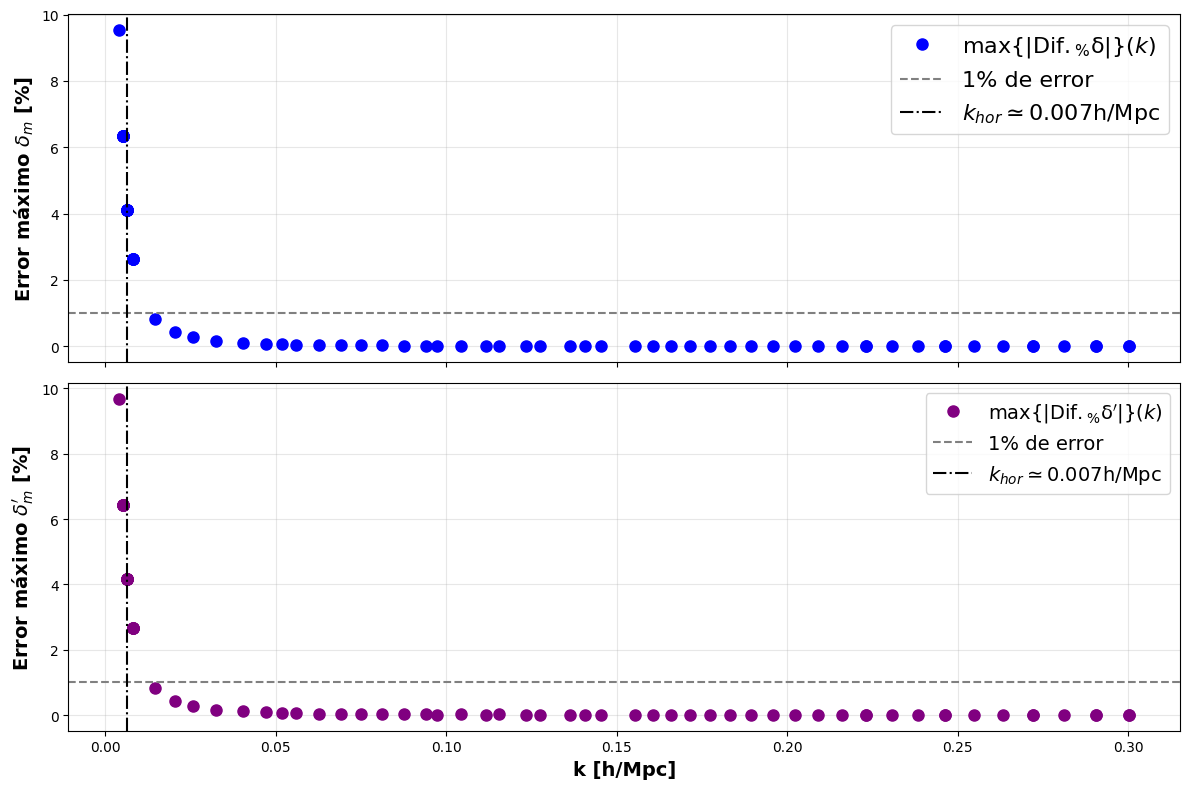

[0.004095505882352941, 0.005155935294117647, 0.005155935294117647, 0.005155935294117647, 0.005155935294117647, 0.005155935294117647, 0.005155935294117647, 0.005155935294117647, 0.006490938235294117, 0.006490938235294117, 0.006490938235294117, 0.006490938235294117, 0.006490938235294117, 0.006490938235294117, 0.006490938235294117]

k [h/Mpc] | Dif. media δ [%] | Dif. media δ' [%]
0.0041    | 9.531          | 9.679
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0052    | 6.342          | 6.440
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0065    | 4.106          | 4.170
0.0082    | 2.623          | 2.664
0.0082    | 2.623       

In [ ]:
#import Line2D
from matplotlib.lines import Line2D
from source.main_functions import NumericalIntegrator
import numpy as np
import matplotlib.pyplot as plt
import os
import source.main_functions as ft

# k_thresholds = np.array([0.002,.005,.010, .1, .5]) #h/Mpc
k_thresholds = np.linspace(0.005, 0.3, 70) # h/Mpc
#agregar mas densidad de puntos a k_thresholds entre 0.005 y 0.007:
k_thresholds = np.concatenate([np.linspace(0.004, 0.007, 20), np.linspace(0.0071, 0.3, 50)])
print(k_thresholds[:4])

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
h = .68
Omega_m = .3

difs_list = []
difs_primes_list = []
k_selected_list = []
if os.path.exists('/home/pedrorozin/scripts/notebooks/delta_prime_cdm.txt'):
    os.remove('/home/pedrorozin/scripts/notebooks/delta_prime_cdm.txt')
M = ft.common_settings(k = 0.01, omega_m= Omega_m, A_s=2.1e-9, h=h)
df_M = ft.get_df_from_M(M)
df_M = df_M.drop_duplicates(subset=['a'], keep='last')

Omega_b = M.Omega_b()
Omega_m_actual = M.Omega_m()
Omega_cdm = Omega_m_actual - Omega_b

# df from adhoc (CLASS en C)
df_adhoc = ft.read_adhoc_txt('/home/pedrorozin/scripts/notebooks/delta_prime_cdm.txt')

# Loop para calcular diferencias para cada k
for i, k_th in enumerate(k_thresholds):
    k_query = k_th * h  # Convertir a unidades de CLASS (1/Mpc)
    # Seleccionar k
    k_selected = df_adhoc[df_adhoc['k'] >= k_query]['k'].min()
    k_selected_list.append(k_selected)
    # print(f'k selected from adhoc: {k_selected}')
    
    df_adhoc_k = df_adhoc[df_adhoc['k'] == k_selected].copy()
    df_adhoc_k = df_adhoc_k.sort_values(by='a').reset_index(drop=True)
    df_adhoc_k = df_adhoc_k.drop_duplicates(subset=['a'], keep='last')
    
    # Calcular delta_m
    delta_cdm_adhoc = df_adhoc_k['delta_cdm'].values
    delta_b_adhoc = df_adhoc_k['delta_b'].values
    delta_m_adhoc = ft.compute_delta_m(delta_cdm_adhoc, delta_b_adhoc, Omega_cdm, Omega_b)
    
    df_adhoc_k['delta_m'] = delta_m_adhoc
    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_cdm')
    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_b')
    delta_prime_m_adhoc = ft.compute_delta_m(
        df_adhoc_k['delta_prime_cdm'].values, 
        df_adhoc_k['delta_prime_b'].values, 
        Omega_cdm, 
        Omega_b
    )
    df_adhoc_k['delta_prime_m'] = delta_prime_m_adhoc
    
    # Integración numérica
    a_query =0.03
    initial_index = np.where(df_adhoc_k['a'] >= a_query)[0][0]
    a_initial = df_adhoc_k['a'].values[initial_index]
    
    # print(f'a_initial: {a_initial}, k_horizon: {k_horizon}h/Mpc, k_selected: {k_selected/h}h/Mpc')
    
    delta_initial = df_adhoc_k['delta_m'].values[initial_index]
    delta_prime_initial = df_adhoc_k['delta_prime_m'].values[initial_index]
    
    integrator = NumericalIntegrator(Om_m_0=Omega_m_actual, a_0=a_initial, sigma8=0.8)
    a_integrated, delta_integrated, delta_prime_integrated = integrator.integrate(delta_initial, delta_prime_initial)
    
    # Limpiar
    
    # Calcular diferencias
    dif = ft.percent_diff_vs_class(a_integrated, delta_integrated, df_adhoc_k['a'], df_adhoc_k['delta_m'])
    dif_primes = ft.percent_diff_vs_class(a_integrated, delta_prime_integrated, df_adhoc_k['a'], df_adhoc_k['delta_prime_m'])
    
    difs_list.append(dif)
    difs_primes_list.append(dif_primes)

# ========================================
# CALCULAR DIFERENCIAS MEDIAS
# ========================================
k_values_h = []
max_dif_delta = []
max_dif_delta_prime = []

k_horizon = ft.k_horizon(a_initial, Omega_m_actual, c=3e5)

print(f'k_horizon at a={a_initial}: {k_horizon} h/Mpc')
for i, k_sel in enumerate(k_selected_list):
    k_values_h.append(k_sel / h)
    max_dif_delta.append(max(np.abs(difs_list[i][-10:])))
    max_dif_delta_prime.append(max(np.abs(difs_primes_list[i][-10:])))

# ========================================
# GRÁFICO DE ERROR MEDIO VS k
# ========================================
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot para delta
axs[0].plot(k_values_h, max_dif_delta, 'o', linewidth=2, markersize=8, color='blue',
            label = r"$\mathrm{max \{|Dif._\% \delta|\}}(k)$")
axs[0].set_ylabel('Error máximo $\delta_m$ [%]', fontweight='bold', fontsize=14)
# axs[0].set_xscale('log')
# axs[0].set_yscale('log')
axs[0].grid(alpha=0.3, which='both')
axs[0].axhline(y=1, color='gray', linestyle='--', linewidth=1.5, label='1% de error')
#vline in k=0.013
axs[0].axvline(x=k_horizon, color='black', linestyle='-.', linewidth=1.5, label=f'$k_{{hor}}\\simeq {k_horizon:.3f}\\mathrm{{h/Mpc}}$')
axs[0].legend(fontsize = 16)

# Plot para delta_prime
# axs[1].plot(k_values_h, mean_dif_delta_prime, 'o', linewidth=2, markersize=8, color='purple', 
#             label = r"$ <\frac{\delta\prime_{CLASS}(a) - \delta\prime_{subh}(a)}{\delta\prime_{CLASS}(a)}>_k\times100\%$ ")
axs[1].plot(k_values_h, max_dif_delta_prime, 'o', linewidth=2, markersize=8, color='purple', 
            label = r"$\mathrm{max \{|Dif._\% \delta^\prime|\}}(k)$")
axs[1].set_ylabel('Error máximo $\delta_m^\prime$ [%]', fontweight='bold', fontsize=14)
axs[1].set_xlabel('k [h/Mpc]', fontweight='bold', fontsize=14)
# axs[1].set_xscale('log')
# axs[1].set_yscale('log')
axs[1].grid(alpha=0.3, which='both')
axs[1].axhline(y=1, color='gray', linestyle='--', linewidth=1.5, label='1% de error')
axs[1].axvline(x=k_horizon, color='black', linestyle='-.', linewidth=1.5, label=f'$k_{{hor}}\\simeq {k_horizon:.3f}\\mathrm{{h/Mpc}}$')
axs[1].legend(fontsize = 14)

plt.tight_layout()

# plt.savefig('/home/pedrorozin/scripts/outputs_pedro/diferencia_media_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()
print(k_values_h[:15])
# Imprimir tabla de valores
print("\n" + "="*60)
print("k [h/Mpc] | Dif. media δ [%] | Dif. media δ' [%]")
print("="*60)
for i in range(len(k_values_h)):
    print(f"{k_values_h[i]:.4f}    | {max_dif_delta[i]:.3f}          | {max_dif_delta_prime[i]:.3f}")
print("="*60)

M.struct_cleanup()
del M


## Comparations CLASS vs subhorizon

### With the grid

In [18]:
#import Line2D
from matplotlib.lines import Line2D
from main_functions import NumericalIntegrator, ImprovedRegressionNN
from delta_solver_mg_pedro import VectorizedDeltaSolver, DeltaSolver
import numpy as np
import matplotlib.pyplot as plt
import os
import main_functions as ft
import torch
import joblib

def red_para_condiciones_iniciales(parametros = [0.03, 0.1, 0.68, 0.3], name ='NN_z_approx_32'):
	""" 
	Initial conditions for delta and delta prime at a_ini, calculated from the trained neural network.
	The neural network takes as input the parameters [a_ini, k, h, Om_m_0] and outputs [delta_ini, delta_p_ini].
	IMPORTANT: You have to change the path to the model and scalers to match your local setup.
	"""
	# device = torch.device('cpu')
	torch.manual_seed(0)
	model = ImprovedRegressionNN(activation='tanh')
	#THIS PATH NEEDS TO BE CHANGED TO MATCH YOUR LOCAL SETUP
	main_path = f'/home/pedrorozin/paper_tesis2025/outputs/neural_networks/' #CHANGE THIS TO MATCH YOUR LOCAL SETUP
	folder_path = str(name)
	network_name = f'_{folder_path}'
	path_model = f'{main_path}{folder_path}/regression_model{network_name}.pth'
	path_scaler_X = f'{main_path}{folder_path}/scaler_X{network_name}.pkl'
	path_scaler_y = f'{main_path}{folder_path}/scaler_y{network_name}.pkl'
	model.load_state_dict(torch.load(path_model))  
	model.eval()
	scaler_X = joblib.load(path_scaler_X)
	scaler_y = joblib.load(path_scaler_y)
	if type(parametros) is dict:
		a = np.array([parametros['a']])
		kh = np.array([parametros['k h']])
		h = np.array([parametros['h']])
		Omega_m = np.array([parametros['Omega_m']])
	elif type(parametros) is list or type(parametros) is np.ndarray:
		a = np.array([parametros[0]])
		kh = np.array([parametros[1]])
		h = np.array([parametros[2]])
		Omega_m = np.array([parametros[3]])
	elif type(parametros) is pd.DataFrame:
		a = np.array([parametros['a'].values[0]])
		kh = np.array([parametros['k h'].values[0]])
		h = np.array([parametros['h'].values[0]])
		Omega_m = np.array([parametros['Omega_m'].values[0]])
	X = np.column_stack((a, kh, h, Omega_m))
	X_scaled = scaler_X.transform(X)
	X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
	with torch.no_grad():
		y_scaled = model(X_tensor).numpy()
	y = scaler_y.inverse_transform(y_scaled)
	delta_ini, delta_p_ini = y[0]
	return [delta_ini, delta_p_ini]
    

In [7]:
k_horizon = ft.k_horizon(0.03, 0.3, c=3e5)
print(f'k_horizon at a=0.03: {k_horizon} h/Mpc')

k_horizon at a=0.03: 0.0066566654221520095 h/Mpc



=== k = 0.05 h/Mpc ===
k pedido: 0.05 h/Mpc -> k elegido: 0.0500 h/Mpc
a_initial = 0.0321, k_horizon = 6.4374e-03 h/Mpc
IC NN: delta=-2.522697e+02, delta_prime=-7.810572e+03
IC CLASS: delta=-2.521161e+02, delta_prime=-7.805852e+03

=== k = 0.1 h/Mpc ===
k pedido: 0.1 h/Mpc -> k elegido: 0.1000 h/Mpc
a_initial = 0.0334, k_horizon = 6.3083e-03 h/Mpc
IC NN: delta=-4.945788e+02, delta_prime=-1.472848e+04
IC CLASS: delta=-4.945873e+02, delta_prime=-1.472800e+04

=== k = 0.2 h/Mpc ===
k pedido: 0.2 h/Mpc -> k elegido: 0.2000 h/Mpc
a_initial = 0.0316, k_horizon = 6.4867e-03 h/Mpc
IC NN: delta=-7.983944e+02, delta_prime=-2.512331e+04
IC CLASS: delta=-7.984351e+02, delta_prime=-2.512355e+04


/tmp/ipykernel_2018/134396266.py:226: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


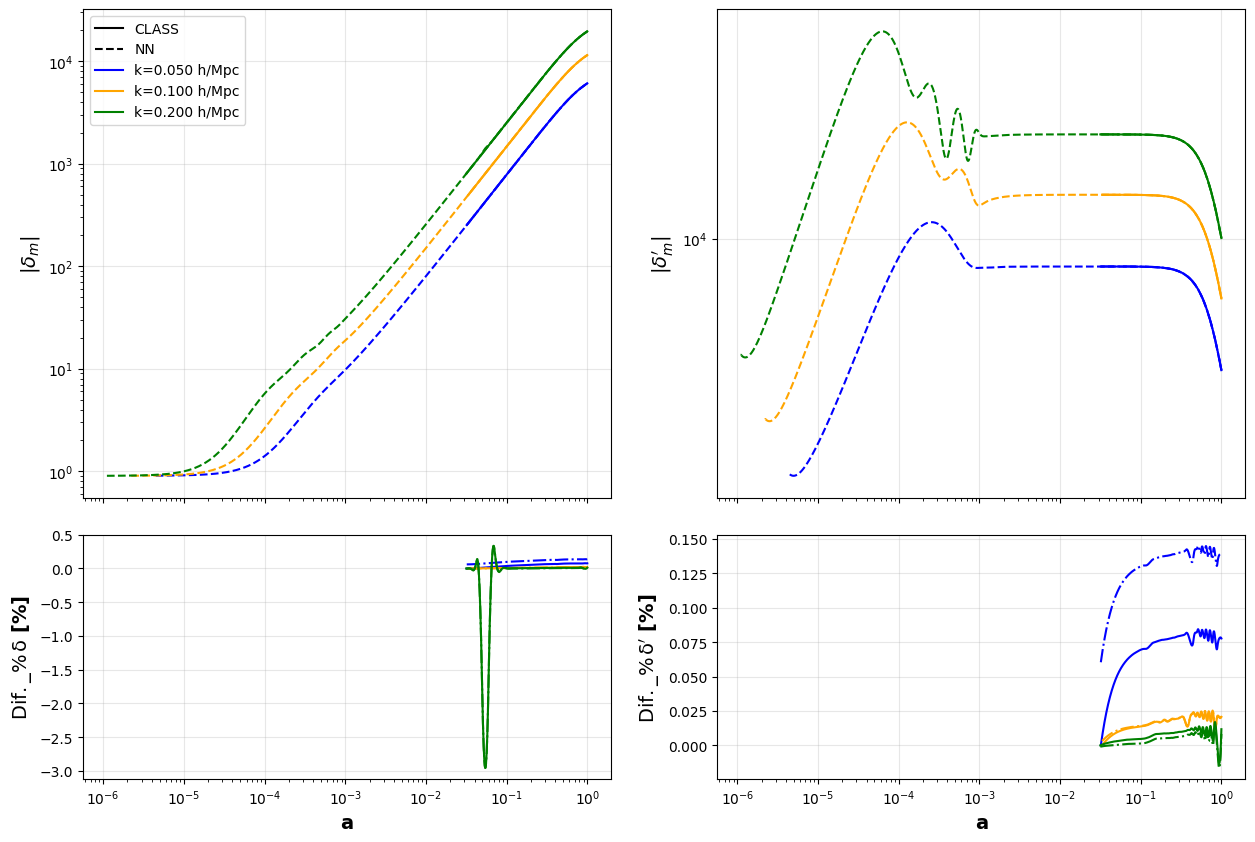

In [34]:
h = 0.68
k_thresholds_h_Mpc = np.array([0.05, 0.10, 0.2], dtype=float)  # k en h/Mpc
k_thresholds_class = k_thresholds_h_Mpc * h  # k en 1/Mpc para CLASS
colors = ['blue', 'orange', 'green', 'red', 'purple', 'magenta']

Omega_m_global = 0.3

k_selected_h_Mpc_list = []

# Guardados para graficar
comparisons = {
    'difs_delta_class': [],
    'difs_delta_nn': [],
    'difs_delta_prime_class': [],
    'difs_delta_prime_nn': [],
    'a_integrated_class': [],
    'a_integrated_nn': [],
    'delta_integrated_class': [],
    'delta_prime_integrated_class': [],
    'delta_integrated_nn': [],
    'delta_prime_integrated_nn': [],
    'df_adhoc': [],
}

path_txt = '/home/pedrorozin/paper_tesis2025/delta_prime_cdm.txt'
if os.path.exists(path_txt):
    os.remove(path_txt)

# Cálculo de referencia de CLASS para la cosmología base
M = ft.common_settings(k=0.01, omega_m=Omega_m_global, A_s=2.1e-9, h=h)
Omega_b = M.Omega_b()
Omega_m_actual = M.Omega_m()
Omega_cdm = Omega_m_actual - Omega_b
M.struct_cleanup()
del M

a_query = 0.03

# ========================================
# LOOP principal: comparación CLASS vs CLASS y NN vs CLASS
# ========================================
for i, (k_h_mpc, k_class) in enumerate(zip(k_thresholds_h_Mpc, k_thresholds_class)):
    print(f'\n=== k = {k_h_mpc} h/Mpc ===')

    # Inicializar CLASS con k en unidades físicas de 1/Mpc
    M = ft.common_settings(k=k_class, omega_m=Omega_m_global, A_s=2.1e-9, h=h)
    Omega_b = M.Omega_b()
    Omega_m = M.Omega_m()
    Omega_cdm = Omega_m - Omega_b

    # Leer archivo adhoc generado por CLASS en C
    df_adhoc = ft.read_adhoc_txt(path_txt)

    # Tomar el k más cercano en el archivo adhoc (también en 1/Mpc)
    k_selected_class = df_adhoc[df_adhoc['k'] >= k_class]['k'].min()
    k_selected_h_mpc = k_selected_class / h
    k_selected_h_Mpc_list.append(k_selected_h_mpc)
    print(f'k pedido: {k_h_mpc} h/Mpc -> k elegido: {k_selected_h_mpc:.4f} h/Mpc')

    df_adhoc_k = df_adhoc[df_adhoc['k'] == k_selected_class].copy()
    df_adhoc_k = df_adhoc_k.sort_values(by='a').reset_index(drop=True)
    df_adhoc_k = df_adhoc_k.drop_duplicates(subset=['a'], keep='last')

    delta_cdm_adhoc = df_adhoc_k['delta_cdm'].values
    delta_b_adhoc = df_adhoc_k['delta_b'].values
    delta_m_adhoc = ft.compute_delta_m(delta_cdm_adhoc, delta_b_adhoc, Omega_cdm, Omega_b)
    df_adhoc_k['delta_m'] = delta_m_adhoc

    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_cdm')
    df_adhoc_k = ft.deriv_tau_to_a(df_adhoc_k, 'delta_dot_b')

    delta_prime_m_adhoc = ft.compute_delta_m(
        df_adhoc_k['delta_prime_cdm'].values,
        df_adhoc_k['delta_prime_b'].values,
        Omega_cdm,
        Omega_b,
    )
    df_adhoc_k['delta_prime_m'] = delta_prime_m_adhoc

    comparisons['df_adhoc'].append(df_adhoc_k.copy())

    # Punto inicial común para ambas integraciones
    initial_index = np.where(df_adhoc_k['a'] >= a_query)[0][0]
    a_initial = df_adhoc_k['a'].values[initial_index]
    k_horizon = ft.k_horizon(a_initial, Omega_m, c=3e5, h=h)
    print(f'a_initial = {a_initial:.4f}, k_horizon = {k_horizon:.4e} h/Mpc')

    delta_initial_class = df_adhoc_k['delta_m'].values[initial_index]
    delta_prime_initial_class = df_adhoc_k['delta_prime_m'].values[initial_index]

    delta_i_NN, delta_p_i_NN = red_para_condiciones_iniciales(
        parametros=[a_initial, k_selected_h_mpc, h, Omega_m],
        name='NN_z_approx_32'
    )
    print(
        f'IC NN: delta={delta_i_NN:.6e}, delta_prime={delta_p_i_NN:.6e}\n'
        f'IC CLASS: delta={delta_initial_class:.6e}, delta_prime={delta_prime_initial_class:.6e}'
    )

    # Integración 1: partir de condiciones iniciales de CLASS
    integrator_class = NumericalIntegrator(Om_m_0=Omega_m, a_0=a_initial, sigma8=0.8)
    a_integrated_class, delta_integrated_class, delta_prime_integrated_class = integrator_class.integrate(
        delta_initial_class, delta_prime_initial_class
    )

    # Integración 2: partir de condiciones iniciales de la red
    integrator_nn = NumericalIntegrator(Om_m_0=Omega_m, a_0=a_initial, sigma8=0.8)
    a_integrated_nn, delta_integrated_nn, delta_prime_integrated_nn = integrator_nn.integrate(
        delta_i_NN, delta_p_i_NN
    )

    # Guardado de resultados
    comparisons['a_integrated_class'].append(a_integrated_class)
    comparisons['a_integrated_nn'].append(a_integrated_nn)
    comparisons['delta_integrated_class'].append(delta_integrated_class)
    comparisons['delta_prime_integrated_class'].append(delta_prime_integrated_class)
    comparisons['delta_integrated_nn'].append(delta_integrated_nn)
    comparisons['delta_prime_integrated_nn'].append(delta_prime_integrated_nn)

    # Diferencias porcentuales con respecto a la referencia de CLASS
    dif_delta_class = ft.percent_diff_vs_class(
        a_integrated_class, delta_integrated_class, df_adhoc_k['a'], df_adhoc_k['delta_m']
    )
    dif_delta_nn = ft.percent_diff_vs_class(
        a_integrated_nn, delta_integrated_nn, df_adhoc_k['a'], df_adhoc_k['delta_m']
    )

    dif_delta_prime_class = ft.percent_diff_vs_class(
        a_integrated_class, delta_prime_integrated_class, df_adhoc_k['a'], df_adhoc_k['delta_prime_m']
    )
    dif_delta_prime_nn = ft.percent_diff_vs_class(
        a_integrated_nn, delta_prime_integrated_nn, df_adhoc_k['a'], df_adhoc_k['delta_prime_m']
    )

    comparisons['difs_delta_class'].append(dif_delta_class)
    comparisons['difs_delta_nn'].append(dif_delta_nn)
    comparisons['difs_delta_prime_class'].append(dif_delta_prime_class)
    comparisons['difs_delta_prime_nn'].append(dif_delta_prime_nn)

    M.struct_cleanup()
    del M

# Eliminar archivo temporal al final
if os.path.exists(path_txt):
    os.remove(path_txt)

# ========================================
# CREAR FIGURA 2x2 CON sharex='col'
# ========================================
fig, axs = plt.subplots(2, 2, figsize=(15, 10),
                        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.1, 'wspace': 0.2},
                        sharex='col')

ax_delta = axs[0, 0]
ax_delta_prime = axs[0, 1]
ax_dif_delta = axs[1, 0]
ax_dif_delta_prime = axs[1, 1]

line_style_elements = [
    Line2D([0], [0], color='black', linestyle='-', label='CLASS'),
    Line2D([0], [0], color='black', linestyle='--', label='NN'),
]
color_elements = []

for i, (k_sel_h_mpc, df_adhoc_k, a_class, a_nn,
        delta_class, delta_prime_class,
        delta_nn, delta_prime_nn,
        dif_delta_class, dif_delta_nn,
        dif_delta_prime_class, dif_delta_prime_nn) in enumerate(zip(
            k_selected_h_Mpc_list,
            comparisons['df_adhoc'],
            comparisons['a_integrated_class'],
            comparisons['a_integrated_nn'],
            comparisons['delta_integrated_class'],
            comparisons['delta_prime_integrated_class'],
            comparisons['delta_integrated_nn'],
            comparisons['delta_prime_integrated_nn'],
            comparisons['difs_delta_class'],
            comparisons['difs_delta_nn'],
            comparisons['difs_delta_prime_class'],
            comparisons['difs_delta_prime_nn'],
        )):
    color = colors[i]

    ax_delta.plot(df_adhoc_k['a'], -df_adhoc_k['delta_m'], linestyle='--', color=color)
    ax_delta.plot(a_class, -delta_class, '-', color=color)
    ax_delta.plot(a_nn, -delta_nn, '-.', color=color)

    ax_delta_prime.plot(df_adhoc_k['a'], -df_adhoc_k['delta_prime_m'], linestyle='--', color=color)
    ax_delta_prime.plot(a_class, -delta_prime_class, '-', color=color)
    ax_delta_prime.plot(a_nn, -delta_prime_nn, '-.', color=color)

    ax_dif_delta.plot(a_class, dif_delta_class, linestyle='-', color=color)
    ax_dif_delta.plot(a_nn, dif_delta_nn, linestyle='-.', color=color)
    ax_dif_delta_prime.plot(a_class, dif_delta_prime_class, linestyle='-', color=color)
    ax_dif_delta_prime.plot(a_nn, dif_delta_prime_nn, linestyle='-.', color=color)

    color_elements.append(
        Line2D([0], [0], color=color, linestyle='-', label=f'k={k_sel_h_mpc:.3f} h/Mpc')
    )

# Configuración visual
ax_delta.set_yscale('log')
ax_delta.set_xscale('log')
ax_delta.set_ylabel(r'$|\delta_m|$', fontweight='bold', fontsize=14)
ax_delta.grid(alpha=0.3)
ax_delta.legend(handles=line_style_elements + color_elements, loc='upper left', fontsize=10)
ax_delta.tick_params(labelbottom=False)

ax_delta_prime.set_yscale('symlog')
ax_delta_prime.set_xscale('log')
ax_delta_prime.set_ylabel(r'$|\delta_m^{\prime}|$', fontweight='bold', fontsize=14)
ax_delta_prime.grid(alpha=0.3)
ax_delta_prime.tick_params(labelbottom=False)

ax_dif_delta.set_xscale('log')
ax_dif_delta.set_ylabel(r'$\mathrm{Dif.\_\%\,\delta}$ [%]', fontweight='bold', fontsize=14)
ax_dif_delta.set_xlabel('a', fontweight='bold', fontsize=14)
ax_dif_delta.grid(alpha=0.3)

ax_dif_delta_prime.set_xscale('log')
ax_dif_delta_prime.set_ylabel(r'$\mathrm{Dif.\_\%\,\delta^{\prime}}$ [%]', fontweight='bold', fontsize=14)
ax_dif_delta_prime.set_xlabel('a', fontweight='bold', fontsize=14)
ax_dif_delta_prime.grid(alpha=0.3)

plt.tight_layout()
plt.show()